<a href="https://colab.research.google.com/github/RayQueen/ucv-svd-image-compression/blob/main/SVDImageCompression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Preparación del entorno


### 0.1.  Sincronización con repositorio de Git Hub

In [ ]:
# Verifica ubicación actual
path = !pwd
path_str = path[0]

# Si el repositorio ya fue clonado intenta actualizar
if path_str == "/content/ucv-svd-image-compression":
    !git pull
# De lo contrario lo clona y corrige la ubicación actual
else:
    !git clone https://github.com/RayQueen/ucv-svd-image-compression.git
    %cd ucv-svd-image-compression/

### 0.2. Librerías necesarias

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Implementación computacional

## 1.1. Carga de una imagen de alta resolución y conversión a matriz de intensidades de gris

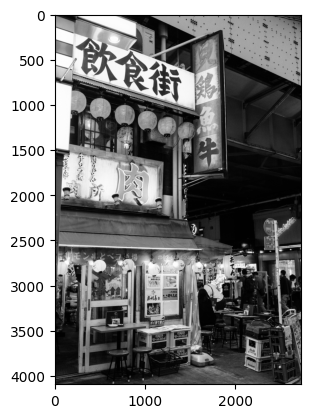

In [33]:
# Abre la imagen a color de alta resolución
originalImg = Image.open('Images/HRImage.jpg')

# Convierte la imagen a escala de grises
grayImg = originalImg.convert('L')

# Guarda la imagen a escala de grises de alta resolución
grayImg.save('Images/grayHRImage.jpg')

# Convierte la imagen a array
grayImgArray = np.asarray(grayImg)

# Muestra la imagen con matplotlib (Temporal)
plt.imshow(grayImgArray, cmap = 'gray')
plt.show()

## 1.2. Cálculo de la SVD de la matriz resultante

Nuestra matriz A será grayImgArray de modo que: A = U * S * Vt,  donde:
- U $\in R^{m×m}$ y Vt $\in R^{n×n}$ son matrices ortogonales
- S es una matriz diagonal con valores singulares $s_1 \geq s_2 \geq ... \geq s_r \geq 0$

In [34]:
# Definimos A para mejor legibilidad
A = grayImgArray

# Calcula las matrices U, S y Vt
U, S, Vt = np.linalg.svd(A)

print("U (Left Singular Vectors):\n", U)
print("S (Singular Values):", S)
print("Vt (Right Singular Vectors - Transposed):\n", Vt)

U (Left Singular Vectors):
 [[-0.01841269  0.00923752  0.00165308 ...  0.02150428 -0.00340842
   0.02386737]
 [-0.01845066  0.00916623  0.00148735 ... -0.0200295  -0.00784032
  -0.02350786]
 [-0.01845907  0.00889348  0.00125746 ...  0.02495083  0.03622614
   0.01535002]
 ...
 [-0.0091408   0.01720603 -0.00561168 ...  0.33356056 -0.20574747
   0.05462908]
 [-0.00912282  0.01743915 -0.00566997 ... -0.20729484  0.30824977
  -0.13668723]
 [-0.00910819  0.01755469 -0.00578148 ...  0.06424801 -0.13448047
   0.1363128 ]]
S (Singular Values): [3.40638451e+05 9.09860915e+04 8.08061737e+04 ... 1.19778263e+01
 1.17050019e+01 1.11042928e+01]
Vt (Right Singular Vectors - Transposed):
 [[-0.02255083 -0.02254582 -0.02253208 ... -0.01234599 -0.01234788
  -0.01235297]
 [ 0.01793824  0.01813554  0.01829452 ...  0.01433404  0.01439012
   0.01438601]
 [-0.0107077  -0.0106493  -0.01058423 ... -0.01406754 -0.01451308
  -0.01481517]
 ...
 [ 0.01518557 -0.03244911  0.03781007 ...  0.01871986  0.00059532
  -0.

## 1.3. Construcción de aproximaciones $A_k$

### 1.3.1.  k = 5

A_k (Reconstructed Image):
 [[15.033048   14.20095805 12.78148682 ... 84.76821216 83.94471527
  83.48492396]
 [15.17804589 14.33799531 12.907606   ... 84.53403014 83.70826168
  83.24626108]
 [14.31298536 13.45840443 12.00989404 ... 84.06406401 83.23554827
  82.77235572]
 ...
 [64.78439266 64.96626342 65.01428766 ... 85.59999131 85.94086636
  86.19247116]
 [65.54835955 65.7364546  65.79108687 ... 85.79976418 86.14520585
  86.39837748]
 [66.77668278 66.97506848 67.04405749 ... 86.18138696 86.53966932
  86.80059145]] 



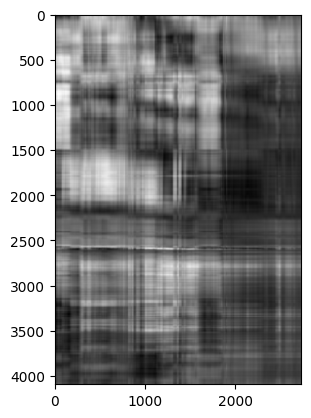

In [35]:
# Reconstruimos la imagen usando solo 5 componentes
k = 5
A_k = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])
print("A_k (Reconstructed Image):\n", A_k, "\n")

# Muestra la imagen con matplotlib (Temporal)
plt.imshow(A_k, cmap = 'gray')
plt.show()

### 1.3.2. k = 20

A_k (Reconstructed Image):
 [[ 4.26618501  5.76855455  6.53209534 ... 73.59121324 72.43634394
  70.78179424]
 [ 6.30873185  7.7735885   8.39189149 ... 73.09208483 72.01436996
  70.43378236]
 [ 7.66229268  9.10956237  9.59134471 ... 71.80191089 70.80805604
  69.31134137]
 ...
 [38.17430483 38.31589588 37.94929402 ... 87.50600192 89.05072746
  90.83912341]
 [37.82595417 38.01266518 37.66575084 ... 88.83398013 90.29511442
  92.04603249]
 [38.59632987 38.81028835 38.5386202  ... 89.93437087 91.27441724
  92.91059553]] 



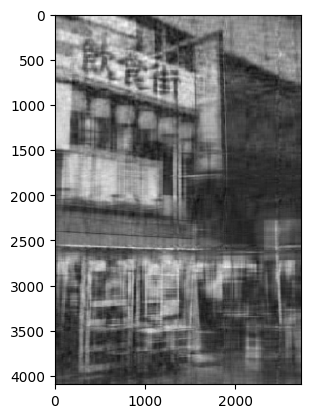

In [36]:
# Reconstruimos la imagen usando solo 5 componentes
k = 20
A_k = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])
print("A_k (Reconstructed Image):\n", A_k, "\n")

# Muestra la imagen con matplotlib (Temporal)
plt.imshow(A_k, cmap = 'gray')
plt.show()

### 1.3.3. k = 50

A_k (Reconstructed Image):
 [[22.99810848 24.54769242 22.9961146  ... 28.01703861 26.89770151
  25.93623446]
 [28.85749918 30.33462368 28.61658646 ... 27.51634337 26.52310599
  25.62090631]
 [32.97513603 34.30951864 32.36901886 ... 25.09982447 24.13378252
  23.25182936]
 ...
 [41.12612832 41.07833436 42.0286917  ... 72.2006309  73.99102191
  76.50676326]
 [40.43690597 40.70681498 41.85615358 ... 71.79596511 73.66358711
  76.36379826]
 [42.15753633 42.73498076 44.06392136 ... 70.99777971 72.95188144
  75.75643154]] 



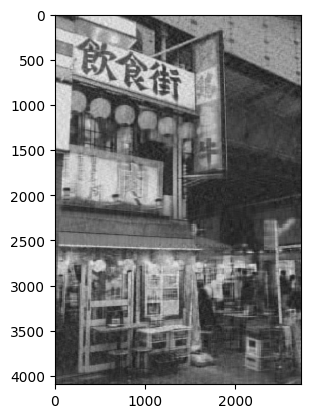

In [37]:
# Reconstruimos la imagen usando solo 5 componentes
k = 50
A_k = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])
print("A_k (Reconstructed Image):\n", A_k, "\n")

# Muestra la imagen con matplotlib (Temporal)
plt.imshow(A_k, cmap = 'gray')
plt.show()

### 1.3.4. k = 100

A_k (Reconstructed Image):
 [[29.64702654 29.94606014 27.35344455 ... 10.05832301 10.20604393
  12.28045419]
 [34.69665226 35.20406103 32.40104502 ... 14.19333263 14.40742157
  16.0238622 ]
 [36.1580905  36.58902834 33.33082661 ... 17.15064946 17.22412021
  18.58860729]
 ...
 [32.52259032 31.17612193 30.1883854  ... 93.09870498 93.84435306
  94.49175941]
 [32.0872398  31.07152903 30.07015051 ... 88.12664766 89.04120002
  89.54364328]
 [32.36138992 31.97617365 31.10062749 ... 82.27739564 83.55841686
  84.45097114]] 



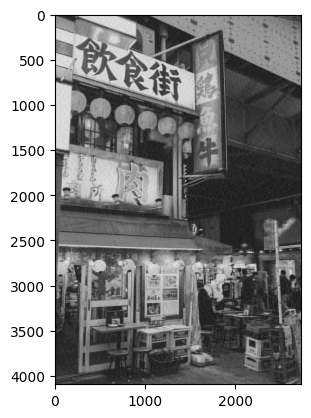

In [38]:
# Reconstruimos la imagen usando solo 5 componentes
k = 100
A_k = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])
print("A_k (Reconstructed Image):\n", A_k, "\n")

# Muestra la imagen con matplotlib (Temporal)
plt.imshow(A_k, cmap = 'gray')
plt.show()

### 1.3.5. k = 200

A_k (Reconstructed Image):
 [[28.75525349 31.01632197 28.6120927  ...  8.56182117 11.0255694
  18.42705711]
 [28.11395295 31.03583638 28.90814041 ...  6.60876816  9.51042447
  17.03670339]
 [27.32935205 31.03184184 29.07143574 ...  5.62217155  8.25214159
  15.14819705]
 ...
 [47.8445556  46.73120539 45.43437258 ... 61.41486038 63.33850273
  68.5237906 ]
 [45.95122864 45.53370597 44.59420216 ... 52.94440782 55.36696333
  59.66133239]
 [42.3591575  42.48154311 42.26930708 ... 47.97967819 51.77822521
  55.37926363]] 



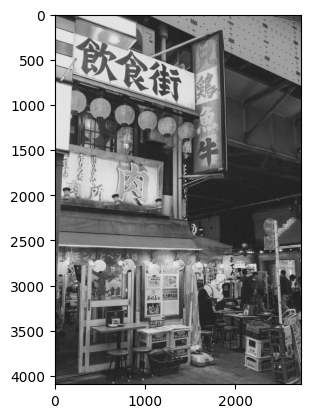

In [39]:
# Reconstruimos la imagen usando solo 5 componentes
k = 200
A_k = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])
print("A_k (Reconstructed Image):\n", A_k, "\n")

# Muestra la imagen con matplotlib (Temporal)
plt.imshow(A_k, cmap = 'gray')
plt.show()

4. Visualización y comparación